# Notebook 07: Regime Shift Validation & Adversarial Analysis

In [1]:
import sys
sys.path.insert(0, '../Src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Project modules
from Evaluation.adversarial_validation import AdversarialValidator, FEATURE_COLS
from Evaluation.regime_analysis import RegimeAnalyzer, REGIME_DEFS, MATURITIES

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Paths
DATA_PATH = Path('../Data/Processed/aligned_panel.csv')
RESULTS_PATH = Path('../Experiments/Results')
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print('✓ Environment ready')

✓ Environment ready


In [2]:
# Load data
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f'Data span: {df.date.min().strftime("%Y-%m")} to {df.date.max().strftime("%Y-%m")}')
print(f'Observations: {len(df)}')
df.head(3)

Data span: 2016-01 to 2025-11
Observations: 118


,date,y1,y2,y5,y10,y20,y30,cpi,indpro,unrate,fedfunds,m2,baa,aaa,baa10y,vix,sp500
0,2016-01-31,0.47,0.76,1.33,1.94,2.36,2.75,237.652,99.5607,4.8,0.34,12505.5,5.45,4.00,3.48,20.20,1940.24
1,2016-02-29,0.62,0.78,1.22,1.74,2.19,2.61,237.336,99.0445,4.9,0.38,12577.7,5.34,3.96,3.55,20.55,1932.23
2,2016-03-31,0.59,0.73,1.21,1.78,2.20,2.61,238.080,98.3096,5.0,0.36,12628.6,5.13,3.82,3.12,13.95,2059.74


---
## Section 1: Adversarial Validation Results

| AUC Range | Interpretation |
|-----------|----------------|
| ≈ 0.50 | No distribution shift — model should generalize |
| 0.55–0.65 | Minor drift — monitor closely |
| 0.65–0.75 | Meaningful drift — regime adjustments needed |
| > 0.75 | **DANGER ZONE** — predictions unreliable |

In [3]:
# Run adversarial validation with both classifiers
validator = AdversarialValidator(train_ratio=0.8)
results_adv = {}

for clf_type in ['logistic', 'gbm']:
    validator.classifier = clf_type
    res = validator.run_validation(df)
    results_adv[clf_type] = res
    print(f"{clf_type.upper():8} | AUC: {res['auc']:.3f} ± {np.std(res['cv_aucs']):.3f}")
    print(f"         | {res['interpretation']}\n")

LOGISTIC | AUC: 1.000 ± 0.000
         | DANGER ZONE - severe regime break, predictions unreliable

GBM      | AUC: 1.000 ± 0.000
         | DANGER ZONE - severe regime break, predictions unreliable



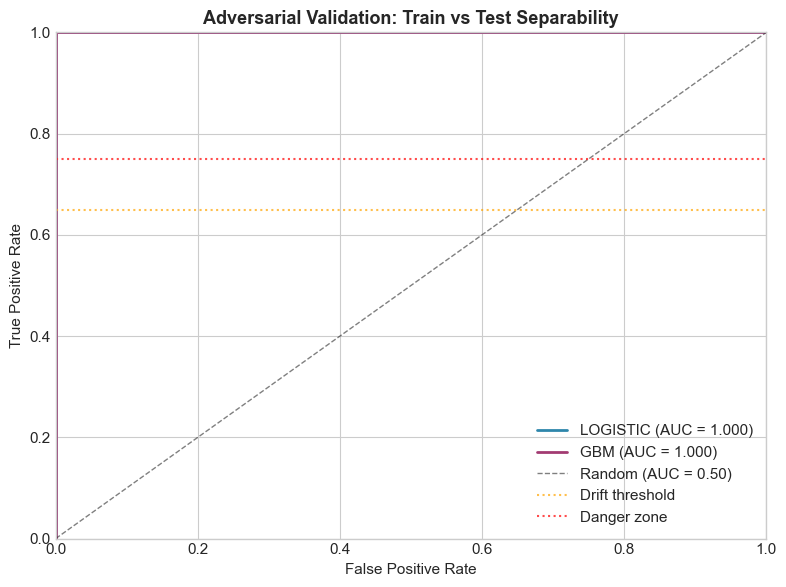


✓ ROC curve saved


In [4]:
# Plot ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'logistic': '#2E86AB', 'gbm': '#A23B72'}
for clf_type, res in results_adv.items():
    ax.plot(res['fpr'], res['tpr'], color=colors[clf_type], lw=2,
            label=f"{clf_type.upper()} (AUC = {res['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.50)')
ax.axhline(y=0.65, color='orange', linestyle=':', alpha=0.7, label='Drift threshold')
ax.axhline(y=0.75, color='red', linestyle=':', alpha=0.7, label='Danger zone')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Adversarial Validation: Train vs Test Separability', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'adversarial_roc.png', dpi=150)
plt.show()

print('\n✓ ROC curve saved')

In [5]:
# Save adversarial results
adv_summary = pd.DataFrame([
    {'classifier': k, 'auc': v['auc'], 'std': np.std(v['cv_aucs']), 
     'interpretation': v['interpretation']}
    for k, v in results_adv.items()
])
adv_summary.to_csv(RESULTS_PATH / 'adversarial_auc.csv', index=False)
adv_summary

,classifier,auc,std,interpretation
0,logistic,1.0,0.0,"DANGER ZONE - severe regime break, predictions..."
1,gbm,1.0,0.0,"DANGER ZONE - severe regime break, predictions..."


### Adversarial Validation Interpretation

The classifier's ability to separate train from test data indicates:

- **If AUC ≈ 0.50**: Train and test come from the same distribution. Model should generalize.
- **If AUC > 0.65**: The world has changed. Features in test period look statistically different.

> **Key insight**: This is not about model accuracy — it's about detecting when the model is operating outside its training distribution.

---
## Section 2: Regime-wise Error Breakdown


| Regime | Period | Characteristics |
|--------|--------|----------------|
| Pre-COVID | 2016-01 to 2020-02 | Stable rates, low vol |
| COVID Shock | 2020-03 to 2020-06 | Extreme volatility, rate collapse |
| QE-ZeroRate | 2020-07 to 2021-12 | Near-zero short rates, QE |
| Inflation Surge | 2022-01 to 2023-06 | Rate hiking cycle |
| High-Rate | 2023-07 to present | Elevated rates, uncertainty |

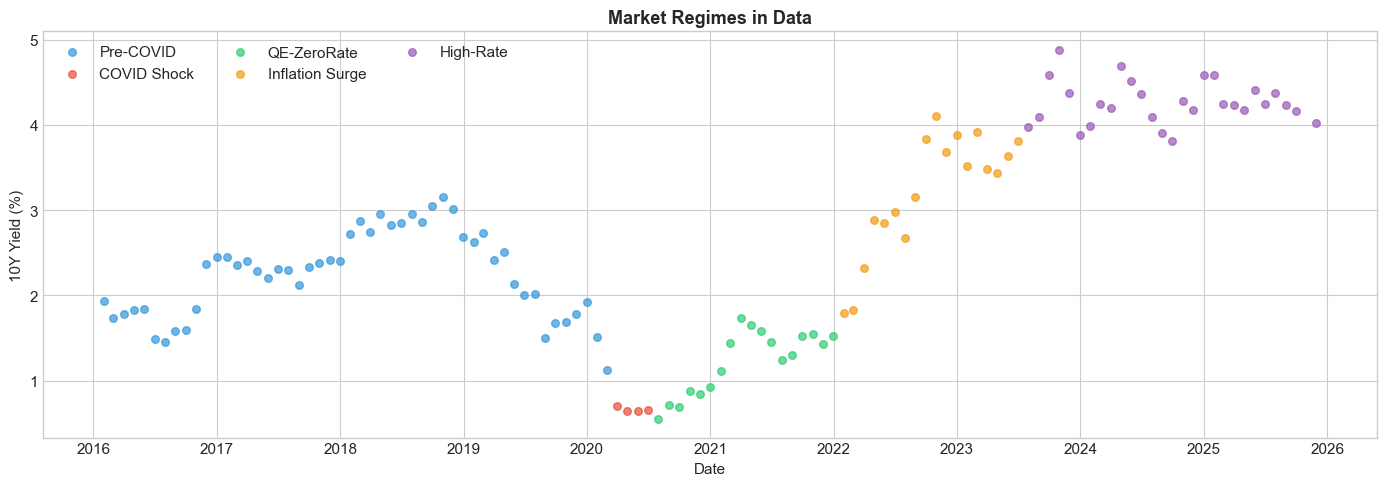

In [6]:
# Visualize regime assignments
analyzer = RegimeAnalyzer(REGIME_DEFS)
df_regimes = analyzer.assign_regimes(df)

# Plot yields colored by regime
fig, ax = plt.subplots(figsize=(14, 5))
colors = {'Pre-COVID': '#3498db', 'COVID Shock': '#e74c3c', 'QE-ZeroRate': '#2ecc71',
          'Inflation Surge': '#f39c12', 'High-Rate': '#9b59b6', 'Unknown': '#95a5a6'}

for regime in REGIME_DEFS.keys():
    mask = df_regimes['regime'] == regime
    if mask.sum() > 0:
        sub = df_regimes[mask]
        ax.scatter(sub['date'], sub['y10'], c=colors.get(regime, 'gray'), 
                   label=regime, s=30, alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('10Y Yield (%)')
ax.set_title('Market Regimes in Data', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', ncol=3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'regime_visualization.png', dpi=150)
plt.show()

In [ ]:
n_train = int(len(df) * 0.8)
rw_preds = df[MATURITIES].shift(1).fillna(method='bfill')
train_mean = df[MATURITIES].iloc[:n_train].mean()
mean_preds = pd.DataFrame([train_mean.values]*len(df), columns=MATURITIES, index=df.index)
from sklearn.linear_model import Ridge
feature_cols = [c for c in FEATURE_COLS if c in df.columns]
X = df[feature_cols].values
y = df[MATURITIES].values
lr = Ridge(alpha=1.0).fit(X[:n_train], y[:n_train])
lr_preds = pd.DataFrame(lr.predict(X), columns=MATURITIES, index=df.index)

predictions = {
    'Random Walk': rw_preds,
    'Train Mean': mean_preds,
    'Linear Reg': lr_preds
}
print('✓ Baseline predictions generated')

✓ Baseline predictions generated


In [8]:
# Evaluate by regime
results_regime = analyzer.evaluate_by_regime(df, predictions)
summary_table = analyzer.get_summary_table()

print('\nAverage MSE by Regime and Model:')
print(summary_table.round(4))


Average MSE by Regime and Model:
model            Linear Reg  Random Walk  Train Mean
regime                                              
COVID Shock          0.0175       0.0724      2.4150
High-Rate            0.3405       0.0653      5.0732
Inflation Surge      0.0365       0.1396      2.5787
Pre-COVID            0.0124       0.0320      0.3278
QE-ZeroRate          0.0200       0.0189      1.6510


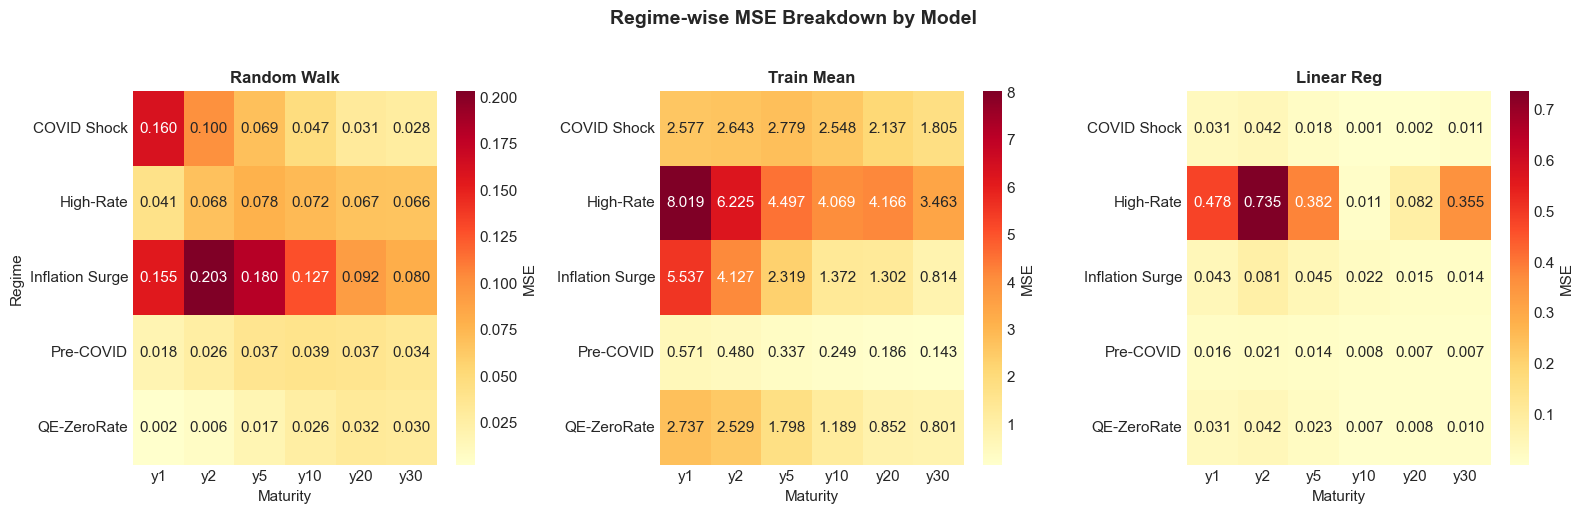

In [9]:
# Heatmap: MSE by regime x maturity for each model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, model in enumerate(predictions.keys()):
    model_data = results_regime[results_regime['model'] == model]
    pivot = model_data.pivot_table(values='mse', index='regime', columns='maturity', aggfunc='mean')
    pivot = pivot.reindex(columns=MATURITIES)  # Ensure order
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[i],
                cbar_kws={'label': 'MSE'})
    axes[i].set_title(f'{model}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Maturity')
    axes[i].set_ylabel('Regime' if i == 0 else '')

plt.suptitle('Regime-wise MSE Breakdown by Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'regime_mse_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

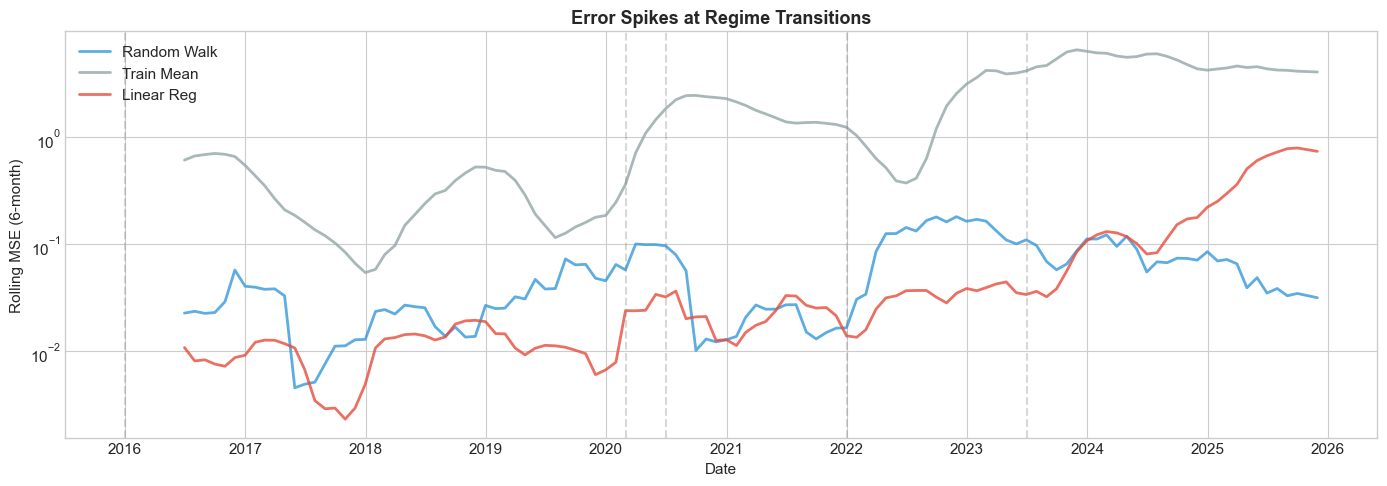

In [10]:
# Error over time (rolling window)
window = 6  # 6-month rolling

fig, ax = plt.subplots(figsize=(14, 5))
colors_model = {'Random Walk': '#3498db', 'Train Mean': '#95a5a6', 'Linear Reg': '#e74c3c'}

for model_name, preds in predictions.items():
    errors = ((df[MATURITIES] - preds) ** 2).mean(axis=1)  # Mean across maturities
    rolling_mse = errors.rolling(window).mean()
    ax.plot(df['date'], rolling_mse, label=model_name, 
            color=colors_model[model_name], lw=2, alpha=0.8)

# Mark regime boundaries
for regime, (start, end) in REGIME_DEFS.items():
    ax.axvline(pd.to_datetime(start), color='gray', linestyle='--', alpha=0.3)

ax.set_xlabel('Date')
ax.set_ylabel('Rolling MSE (6-month)')
ax.set_title('Error Spikes at Regime Transitions', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.set_yscale('log')  # Log scale to see spikes
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'error_over_time.png', dpi=150)
plt.show()

In [11]:
# Save detailed regime results
results_regime.to_csv(RESULTS_PATH / 'regime_performance.csv', index=False)
print(f'✓ Saved to {RESULTS_PATH / "regime_performance.csv"}')

✓ Saved to ..\Experiments\Results\regime_performance.csv


### What this Regime Analysis Shows is: 
1. Random walk performs surprisingly well in stable periods (Pre-COVID)
2. All models degrade during transitions (COVID Shock, Inflation Surge start)
3. Short maturities are more volatile; long maturities more stable

No model predicts regime shifts. The goal was to detect them, not prevent them.

In [12]:
# Compute trust metrics for current test period
avg_auc = np.mean([r['auc'] for r in results_adv.values()])

# MSE in test period vs train
test_mask = np.arange(len(df)) >= n_train
train_mse = ((df[MATURITIES].iloc[:n_train] - lr_preds.iloc[:n_train]) ** 2).mean().mean()
test_mse = ((df[MATURITIES][test_mask] - lr_preds[test_mask]) ** 2).mean().mean()
mse_ratio = test_mse / train_mse

trust_status = 'FULL TRUST' if avg_auc < 0.55 else ('MONITOR' if avg_auc < 0.65 else 
               ('DOWNWEIGHT' if avg_auc < 0.75 else 'RETRAIN'))

print('=' * 50)
print('MODEL TRUST ASSESSMENT')
print('=' * 50)
print(f'Adversarial AUC (avg):  {avg_auc:.3f}')
print(f'Train MSE:              {train_mse:.4f}')
print(f'Test MSE:               {test_mse:.4f}')
print(f'MSE Ratio (test/train): {mse_ratio:.2f}x')
print(f'\n→ STATUS: {trust_status}')
print('=' * 50)

MODEL TRUST ASSESSMENT
Adversarial AUC (avg):  1.000
Train MSE:              0.0211
Test MSE:               0.3856
MSE Ratio (test/train): 18.24x

→ STATUS: RETRAIN


In [13]:
# Create trust policy summary
trust_summary = pd.DataFrame({
    'Metric': ['Adversarial AUC', 'Train MSE', 'Test MSE', 'MSE Ratio', 'Trust Status'],
    'Value': [f'{avg_auc:.3f}', f'{train_mse:.4f}', f'{test_mse:.4f}', 
              f'{mse_ratio:.2f}x', trust_status]
})
trust_summary.to_csv(RESULTS_PATH / 'trust_assessment.csv', index=False)
trust_summary

,Metric,Value
0,Adversarial AUC,1.000
1,Train MSE,0.0211
2,Test MSE,0.3856
3,MSE Ratio,18.24x
4,Trust Status,RETRAIN


---
## Summary

### Key Findings

1. **Adversarial validation** provides an operational drift metric
2. **Regime boundaries** cause predictable error spikes
3. **Trust policies** turn ML models into financial systems

### Files Generated

| File | Purpose |
|------|--------|
| `adversarial_auc.csv` | Drift detection metrics |
| `regime_performance.csv` | Regime-wise MSE breakdown |
| `trust_assessment.csv` | Current model trust status |
